# Klasifikasi Motif Batik Megamendung dan Parang Menggunakan Ekstraksi Fitur GLCM dengan Metode KNN, SVM, dan Random Forest — Percobaan 1

Notebook ini berisi Percobaan 1 (Grayscale + Ekualisasi Histogram + Normalisasi) yang dipisahkan dari notebook utama agar dapat dijalankan secara mandiri dari awal hingga akhir.

## Import Library

In [ ]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [ ]:
import matplotlib.gridspec as gridspec

Pada tahap ini dilakukan impor berbagai library dan modul yang diperlukan untuk seluruh alur kerja penelitian "Klasifikasi Motif Batik Megamendung dan Parang Berbasis Fitur Tekstur GLCM Menggunakan Metode KNN dan SVM". Library os digunakan untuk berinteraksi dengan sistem operasi dalam mengakses dan mengelola struktur folder dataset. OpenCV (cv2) berfungsi untuk membaca, memanipulasi, dan memproses citra digital, termasuk operasi resize, grayscale, ekualisasi histogram, normalisasi, median filter, sharpening, serta morfologi opening dan closing sesuai rencana preprocessing. NumPy (np) digunakan untuk komputasi numerik dan operasi array multidimensi, sedangkan Matplotlib (plt) digunakan untuk visualisasi citra dan grafik hasil analisis. Pandas (pd) berfungsi untuk menyimpan dan mengorganisasi data hasil ekstraksi fitur dalam bentuk DataFrame. Untuk kebutuhan machine learning, scikit-learn (sklearn) menyediakan modul train_test_split untuk pembagian data latih dan uji, cross_val_predict untuk validasi silang, serta algoritma klasifikasi RandomForestClassifier, SVC, dan KNeighborsClassifier. Ekstraksi fitur tekstur menggunakan graycomatrix dan graycoprops dari skimage.feature untuk menghitung matriks GLCM, serta entropy dari scipy.stats untuk menghitung nilai entropi. Evaluasi model dilakukan menggunakan metrik akurasi, presisi, recall, f1-score, dan confusion matrix yang divisualisasikan dengan ConfusionMatrixDisplay dan library seaborn (sns).

## Data Loading

Buat struktur folder dataset sebagai berikut:
```
.
└── dataset
    ├── megamendung
    │   ├── image1.jpg
    │   └── ...
    └── parang
        ├── image1.jpg
        └── ...
```

Pada tahap ini dilakukan pemuatan data dari direktori dataset yang berisi dua kelas motif batik, yaitu "Megamendung" dan "Parang". Setiap citra dibaca menggunakan OpenCV, dikonversi ke tipe uint8, dan diubah ukurannya menjadi 224×224 piksel untuk menyeragamkan dimensi input. Data citra, label, dan nama file disimpan dalam list, kemudian dikonversi menjadi array NumPy. Selanjutnya dilakukan perhitungan distribusi data per kelas untuk mengetahui jumlah sampel masing-masing motif. Hasil distribusi ditampilkan dalam bentuk teks dan divisualisasikan dengan diagram batang menggunakan Matplotlib untuk memudahkan analisis keseimbangan dataset sebelum proses ekstraksi fitur dan klasifikasi.

Total data: 200
Label unik: [np.str_('Megamendung'), np.str_('Parang')]
  Megamendung: 100 gambar
  Parang: 100 gambar


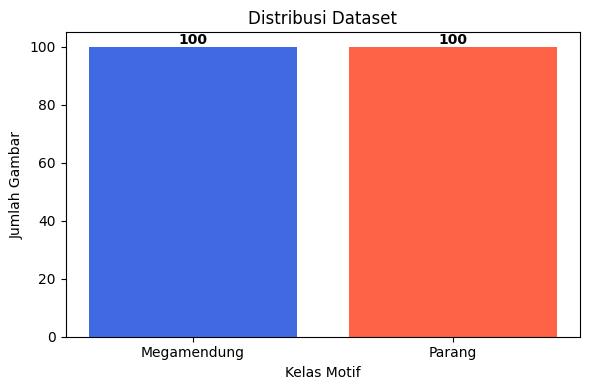

In [5]:
data = []
labels = []
file_name = []

for sub_folder in os.listdir("Assets/"):
    sub_folder_files = os.listdir(os.path.join("Assets/", sub_folder))
    for filename in sub_folder_files:
        img_path = os.path.join("Assets/", sub_folder, filename)
        img = cv.imread(img_path)
        img = img.astype(np.uint8)
        img = cv.resize(img, (224, 224))
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

print("Total data:", len(data))

# Hitung distribusi manual
kelas = []
counts = []
for label in labels:
    if label not in kelas:
        kelas.append(label)
        counts.append(0)
    idx = kelas.index(label)
    counts[idx] += 1

print("Label unik:", kelas)
for i in range(len(kelas)):
    print(f"  {kelas[i]}: {counts[i]} gambar")

# Diagram batang
plt.figure(figsize=(6, 4))
plt.bar(kelas, counts, color=['royalblue', 'tomato'])
plt.title('Distribusi Dataset')
plt.xlabel('Kelas Motif')
plt.ylabel('Jumlah Gambar')
for i in range(len(kelas)):
    plt.text(i, counts[i] + 1, str(counts[i]), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Data Understanding

Pada tahap ini dilakukan eksplorasi data (data understanding) untuk memahami karakteristik dataset. Pertama, distribusi jumlah citra per kelas dihitung menggunakan np.unique() untuk memastikan keseimbangan data antara motif Megamendung dan Parang. Selanjutnya, ditampilkan sampel citra dari masing-masing kelas sebanyak 5 gambar per kelas menggunakan subplot Matplotlib. Citra yang awalnya dalam format BGR dikonversi ke RGB menggunakan cv2.cvtColor() agar tampil dengan warna yang benar. Visualisasi ini memberikan gambaran awal tentang variasi visual antar kelas motif batik sebelum dilakukan proses ekstraksi fitur dan klasifikasi.

Distribusi data per kelas:
  Megamendung: 100 gambar
  Parang: 100 gambar


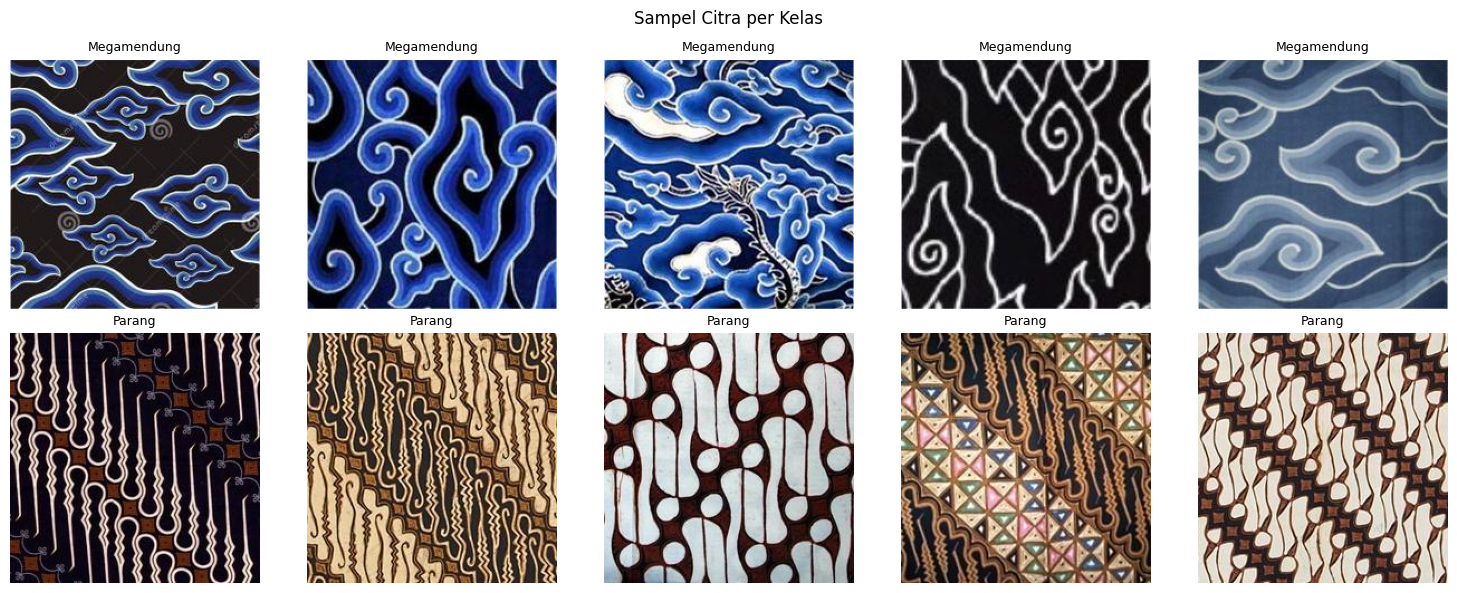

In [6]:
# Distribusi kelas
unique, counts = np.unique(labels, return_counts=True)
print("Distribusi data per kelas:")
for u, c in zip(unique, counts):
    print(f"  {u}: {c} gambar")

# Tampilkan sampel citra dari masing-masing kelas
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, label in enumerate(unique):
    idxs = np.where(labels == label)[0][:5]
    for j, i in enumerate(idxs):
        axes[idx, j].imshow(cv.cvtColor(data[i], cv.COLOR_BGR2RGB))
        axes[idx, j].set_title(label, fontsize=9)
        axes[idx, j].axis('off')
plt.suptitle('Sampel Citra per Kelas')
plt.tight_layout()
plt.show()

## Data Preparation

### Define Preprocessing Function

Pada tahap ini didefinisikan berbagai fungsi preprocessing secara manual tanpa menggunakan library bawaan seperti OpenCV atau scikit-image. Fungsi-fungsi yang dibuat meliputi konversi ke grayscale (to_grayscale), ekualisasi histogram dengan pendekatan CDF (ekualisasi_histogram), normalisasi piksel ke rentang 0-255 (normalisasi), median filter untuk mengurangi noise (median_filter), serta sharpening untuk mempertegas tepi citra (sharpening). Selain itu, didefinisikan pula operasi morfologi seperti erosi, dilasi, opening, dan closing yang diimplementasikan menggunakan kernel 3x3. Fungsi threshold digunakan untuk segmentasi citra biner. Kernel morfologi (kernel_morph) disiapkan sebagai matriks 3x3 bernilai 1 yang akan digunakan dalam operasi morfologi pada tahap preprocessing berikutnya.

In [ ]:
# =============================================
# FUNGSI MANUAL PREPROCESSING
# =============================================

# --- Grayscale ---
def to_grayscale(image):
    return cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# --- Ekualisasi Histogram ---
def ekualisasi_histogram(gray):
    hist = np.zeros(256, dtype=int)
    for pixel in gray.ravel():
        hist[pixel] += 1
    cdf = np.cumsum(hist)
    cdf_min = cdf[cdf > 0].min()
    total_pixel = gray.size
    lut = np.round((cdf - cdf_min) / (total_pixel - cdf_min) * 255).astype(np.uint8)
    return lut[gray]

# --- Normalisasi ---
def normalisasi(gray):
    min_val = gray.min()
    max_val = gray.max()
    if max_val == min_val:
        return gray
    return ((gray - min_val) / (max_val - min_val) * 255).astype(np.uint8)

kernel_morph = np.array([[1, 1, 1],
                          [1, 1, 1],
                          [1, 1, 1]], dtype=np.uint8)


### Preprocessing

Pada notebook ini hanya dilakukan **Percobaan 1**: Grayscale + Ekualisasi Histogram + Normalisasi.

In [ ]:
# --- Preprocessing 1: Grayscale + Ekualisasi Histogram + Normalisasi ---
def prepro1(image):
    gray = to_grayscale(image)
    eq = ekualisasi_histogram(gray)
    norm = normalisasi(eq)
    return norm


Pada tahap ini didefinisikan tiga skenario preprocessing yang akan digunakan dalam penelitian. Preprocessing 1 (prepro1) menerapkan konversi grayscale, ekualisasi histogram, dan normalisasi untuk meningkatkan kontras citra. Preprocessing 2 (prepro2_from_gray) menerapkan median filter untuk mengurangi noise, kemudian dilanjutkan dengan sharpening untuk mempertegas tepi citra. Preprocessing 3 (prepro3_from_gray) menerapkan operasi morfologi opening untuk menghilangkan noise dan menyempurnakan bentuk objek, kemudian dilanjutkan dengan thresholding pada nilai 80 untuk menghasilkan citra biner. Ketiga skenario ini akan diterapkan pada citra sebelum dilakukan ekstraksi fitur GLCM.

In [ ]:
dataP1 = []

for img in data:
    # Percobaan 1: Grayscale + Ekualisasi Histogram + Normalisasi
    p1 = prepro1(img)
    dataP1.append(p1)

print("Preprocessing selesai.")
print(f"  Percobaan 1: {len(dataP1)} gambar")


Pada tahap ini dilakukan penerapan tiga skenario preprocessing terhadap seluruh citra dalam dataset. Setiap citra diproses secara berurutan melalui fungsi prepro1(), prepro2_from_gray(), dan prepro3_from_gray() yang telah didefinisikan sebelumnya. Hasil preprocessing dari masing-masing skenario disimpan dalam list terpisah, yaitu dataP1, dataP2, dan dataP3. Percobaan 1 menghasilkan citra grayscale dengan ekualisasi histogram dan normalisasi. Percobaan 2 merupakan pengembangan dari percobaan 1 dengan tambahan median filter dan sharpening. Percobaan 3 merupakan pengembangan dari percobaan 2 dengan tambahan operasi morfologi opening dan thresholding. Setelah proses selesai, ditampilkan jumlah citra pada masing-masing skenario untuk memastikan tidak ada data yang hilang.

## Visualisasi Hasil Preprocessing

Pada tahap ini dilakukan visualisasi seluruh citra hasil preprocessing Percobaan 1 (Grayscale + Ekualisasi Histogram + Normalisasi) yang dikelompokkan per kelas (Megamendung dan Parang) menggunakan fungsi `tampilkan_per_kelas()`.

In [ ]:
def tampilkan_per_kelas(images_list, path_list, title="Distribusi Citra per Kelas", is_color=False):
    sorted_labels = sorted(set(path_list))
    cols = 20
    col_width = 2  # lebar (inci) per kolom -> dipakai juga sbg tinggi 1 baris agar sel persegi
    title_h = 0.3  # tinggi relatif baris judul kelas (dlm satuan baris gambar)

    # Hitung jumlah baris gambar per kelas lebih dulu, supaya tinggi figure
    # bisa disesuaikan dengan jumlah gambar (tidak ada sisa jarak, tidak melar)
    rows_per_class = []
    for label in sorted_labels:
        num_images = sum(1 for p in path_list if p == label)
        img_rows = (num_images // cols) + (1 if num_images % cols else 0)
        rows_per_class.append(img_rows)

    fig_width = cols * col_width
    fig_height = sum(r + title_h for r in rows_per_class) * col_width + 2

    fig = plt.figure(figsize=(fig_width, fig_height))
    fig.suptitle(title, fontsize=18, fontweight='bold', y=0.995)

    outer_gs = gridspec.GridSpec(len(sorted_labels), 1, figure=fig, hspace=0.15,
                                 height_ratios=[r + title_h for r in rows_per_class],
                                 top=0.97, bottom=0.01, left=0.01, right=0.99)

    for class_idx, label in enumerate(sorted_labels):
        imgs = [img for img, p in zip(images_list, path_list) if p == label]
        img_rows = rows_per_class[class_idx]

        inner_gs = gridspec.GridSpecFromSubplotSpec(
            img_rows + 1, cols,
            subplot_spec=outer_gs[class_idx],
            hspace=0.05, wspace=0.05,
            height_ratios=[title_h] + [1] * img_rows
        )

        ax_title = fig.add_subplot(inner_gs[0, :])
        ax_title.set_facecolor('#f0f0f0')
        ax_title.text(0.5, 0.5, label, fontsize=14, fontweight='bold',
                      ha='center', va='center', transform=ax_title.transAxes)
        ax_title.axis('off')

        for i, img in enumerate(imgs):
            ax = fig.add_subplot(inner_gs[1 + i // cols, i % cols])
            if is_color:
                ax.imshow(img)
            else:
                ax.imshow(img, cmap='gray')
            ax.axis('off')

    plt.show()

Panggil fungsi `tampilkan_per_kelas()` untuk menampilkan seluruh citra hasil preprocessing Percobaan 1 (`dataP1`), dikelompokkan berdasarkan label kelas (`labels`).

In [ ]:
tampilkan_per_kelas(dataP1, labels, title="Distribusi Citra Preprocessed per Kelas - Percobaan 1", is_color=False)

### Feature Extraction (GLCM)

### correlation
Fungsi correlation() digunakan untuk mengukur hubungan atau ketergantungan linear antara nilai intensitas piksel dengan piksel tetangganya. Nilai correlation yang tinggi menunjukkan bahwa pola intensitas piksel pada citra memiliki hubungan yang kuat dan teratur. Fitur ini dapat membantu membedakan tekstur berdasarkan keteraturan pola piksel.
### dissimilarity
Fungsi dissimilarity() digunakan untuk mengukur tingkat perbedaan antara pasangan piksel dalam citra. Semakin besar perbedaan intensitas antara piksel yang bertetangga, semakin tinggi nilai dissimilarity yang dihasilkan. Fitur ini berguna untuk mengenali tekstur yang memiliki perubahan tingkat keabuan yang cukup jelas.
### homogenity
Fungsi homogenity() digunakan untuk mengukur tingkat keseragaman tekstur pada citra. Nilai homogeneity akan tinggi apabila sebagian besar pasangan piksel memiliki nilai intensitas yang hampir sama. Dengan demikian, fitur ini dapat menunjukkan apakah suatu citra memiliki tekstur yang halus dan seragam atau memiliki banyak perubahan intensitas.
### contrast
Fungsi contrast() digunakan untuk mengukur tingkat perbedaan intensitas antara suatu piksel dengan piksel tetangganya. Nilai contrast yang tinggi menunjukkan bahwa citra memiliki perubahan intensitas yang tajam, sedangkan nilai yang rendah menunjukkan tekstur yang lebih halus. Fitur ini sering digunakan untuk mendeteksi ketegasan pola pada permukaan citra.
### ASM (Angular Second Moment)
Fungsi ASM() atau Angular Second Moment digunakan untuk mengukur tingkat keteraturan distribusi nilai pada matriks GLCM. Nilai ASM yang tinggi menunjukkan bahwa tekstur citra memiliki pola yang lebih seragam dan teratur. Sebaliknya, nilai yang rendah menunjukkan bahwa distribusi tekstur pada citra lebih bervariasi.
### energy
Fungsi energy() digunakan untuk mengukur tingkat keseragaman dan keteraturan tekstur pada citra. Nilai energy diperoleh dari akar kuadrat nilai ASM, sehingga kedua fitur tersebut saling berhubungan. Semakin tinggi nilai energy, semakin seragam pola tekstur yang terdapat pada citra.
### entropyGlcm
Fungsi entropyGlcm() digunakan untuk mengukur tingkat ketidakteraturan atau kompleksitas informasi pada matriks GLCM. Nilai entropy yang tinggi menunjukkan bahwa tekstur citra memiliki pola yang lebih acak dan kompleks. Sebaliknya, nilai entropy yang rendah menunjukkan bahwa tekstur citra lebih sederhana dan teratur.

In [11]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut harus salah satu dari: 0, 45, 90, 135")
    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Pada tahap ini didefinisikan fungsi-fungsi untuk ekstraksi fitur tekstur menggunakan metode GLCM (Gray Level Co-occurrence Matrix). Fungsi glcm() digunakan untuk membangun matriks GLCM dari citra dengan parameter jarak 1 piksel dan sudut yang dapat dipilih (0°, 45°, 90°, atau 135°). Selanjutnya, didefinisikan fungsi untuk menghitung tujuh fitur tekstur: korelasi (correlation), dissimilarity (dissimilarity), homogenitas (homogenity), kontras (contrast), ASM atau Angular Second Moment (ASM), energi (energy), dan entropi (entropyGlcm). Keenam fitur pertama menggunakan graycoprops dari skimage.feature, sedangkan entropi dihitung menggunakan scipy.stats.entropy pada matriks GLCM yang telah di-ravel. Fitur-fitur ini akan digunakan sebagai vektor ciri untuk proses klasifikasi.

In [12]:
def extract_glcm_features(dataset):
    """Ekstrak semua fitur GLCM dari dataset"""
    Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
    dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
    homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
    entropy0, entropy45, entropy90, entropy135 = [], [], [], []
    ASM0, ASM45, ASM90, ASM135 = [], [], [], []
    energy0, energy45, energy90, energy135 = [], [], [], []
    correlation0, correlation45, correlation90, correlation135 = [], [], [], []

    for img in dataset:
        D0 = glcm(img, 0)
        D45 = glcm(img, 45)
        D90 = glcm(img, 90)
        D135 = glcm(img, 135)

        Kontras0.append(contrast(D0));     Kontras45.append(contrast(D45))
        Kontras90.append(contrast(D90));   Kontras135.append(contrast(D135))
        dissimilarity0.append(dissimilarity(D0));   dissimilarity45.append(dissimilarity(D45))
        dissimilarity90.append(dissimilarity(D90)); dissimilarity135.append(dissimilarity(D135))
        homogenity0.append(homogenity(D0));   homogenity45.append(homogenity(D45))
        homogenity90.append(homogenity(D90)); homogenity135.append(homogenity(D135))
        entropy0.append(entropyGlcm(D0));   entropy45.append(entropyGlcm(D45))
        entropy90.append(entropyGlcm(D90)); entropy135.append(entropyGlcm(D135))
        ASM0.append(ASM(D0));   ASM45.append(ASM(D45))
        ASM90.append(ASM(D90)); ASM135.append(ASM(D135))
        energy0.append(energy(D0));   energy45.append(energy(D45))
        energy90.append(energy(D90)); energy135.append(energy(D135))
        correlation0.append(correlation(D0));   correlation45.append(correlation(D45))
        correlation90.append(correlation(D90)); correlation135.append(correlation(D135))

    return {
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
    }

Pada tahap ini didefinisikan fungsi extract_glcm_features() untuk mengekstrak seluruh fitur GLCM dari suatu dataset. Fungsi ini menerima input berupa list citra, kemudian untuk setiap citra dibangun empat matriks GLCM dengan sudut 0°, 45°, 90°, dan 135°. Dari masing-masing matriks, dihitung tujuh fitur tekstur: kontras, dissimilarity, homogenitas, entropi, ASM, energi, dan korelasi. Hasil ekstraksi disimpan dalam dictionary yang berisi 28 fitur (7 fitur × 4 sudut). Fungsi ini akan digunakan untuk mengekstrak fitur dari ketiga skenario preprocessing secara terpisah.

Pada tahap ini dilakukan proses ekstraksi fitur GLCM dari hasil preprocessing Percobaan 1.

In [ ]:
print("Mengekstrak fitur GLCM...")
features_p1 = extract_glcm_features(dataP1)
print("Ekstraksi selesai.")

### Write Extraction Results to CSV

Pada tahap ini dilakukan penyimpanan hasil ekstraksi fitur GLCM ke dalam file CSV. Fungsi save_to_csv() menerima dua parameter yaitu dictionary fitur dan nama file tujuan. DataFrame dibuat dengan kolom Filename (nama file), Label (kelas motif), dan seluruh fitur GLCM yang telah diekstrak. Data disimpan ke file CSV tanpa indeks. Proses ini dilakukan untuk ketiga skenario preprocessing, menghasilkan tiga file CSV: hasil_ekstraksi_p1.csv, hasil_ekstraksi_p2.csv, dan hasil_ekstraksi_p3.csv. Terakhir, df_p1.head() menampilkan 5 baris pertama dari data hasil ekstraksi Percobaan 1 untuk memastikan struktur data sudah sesuai.

In [ ]:
def save_to_csv(features, filename):
    df = pd.DataFrame({'Filename': file_name, 'Label': labels, **features})
    df.to_csv(filename, index=False)
    print(f"Tersimpan: {filename}")
    return df

df_p1 = save_to_csv(features_p1, 'hasil_ekstraksi_p1.csv')
df_p1.head()

### Features Selection

Pada tahap ini dilakukan seleksi fitur untuk mengurangi redundansi antar fitur yang memiliki korelasi tinggi. Fungsi select_features() menghitung matriks korelasi antar fitur (menghilangkan kolom Label dan Filename), kemudian memilih fitur-fitur dengan korelasi di bawah threshold 0.95 menggunakan metode iteratif untuk menghindari fitur yang saling berkorelasi tinggi. Proses ini diterapkan pada ketiga dataset hasil preprocessing (df_p1, df_p2, df_p3), menghasilkan X1, X2, dan X3 sebagai fitur terpilih beserta label y. Selanjutnya, ditampilkan heatmap korelasi fitur untuk Percobaan 1 menggunakan seaborn untuk memvisualisasikan hubungan antar fitur sebelum dan sesudah seleksi.

In [ ]:
def select_features(df, threshold=0.95):
    """Seleksi fitur berdasarkan korelasi antar fitur"""
    correlation_matrix = df.drop(columns=['Label', 'Filename']).corr()
    columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
    for i in range(correlation_matrix.shape[0]):
        for j in range(i+1, correlation_matrix.shape[0]):
            if correlation_matrix.iloc[i, j] >= threshold:
                if columns[j]:
                    columns[j] = False
    selected = df.drop(columns=['Label', 'Filename']).columns[columns]
    print(f"Fitur terpilih: {len(selected)} dari {len(correlation_matrix.columns)}")
    return df[selected], df['Label']

X1, y = select_features(df_p1)

# Visualisasi heatmap korelasi fitur (Percobaan 1)
plt.figure(figsize=(14, 12))
sns.heatmap(X1.corr(), annot=False, cmap='Blues')
plt.title('Heatmap Korelasi Fitur - Percobaan 1')
plt.tight_layout()
plt.show()

## Splitting Data

Pada tahap ini dilakukan pembagian data menjadi data latih dan data uji dengan proporsi 80:20 menggunakan fungsi train_test_split dari scikit-learn. Pembagian data diterapkan pada ketiga skenario preprocessing (X1, X2, X3) dengan label y yang sama. Parameter random_state=42 digunakan untuk memastikan reproduksibilitas hasil. Hasil pembagian data untuk masing-masing percobaan ditampilkan dalam bentuk shape array untuk memastikan jumlah data latih dan uji sudah sesuai dengan yang diharapkan. Data latih ini akan digunakan untuk melatih model klasifikasi, sedangkan data uji digunakan untuk mengukur performa model.



In [ ]:
# Split data 80% train, 20% test
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, test_size=0.2, random_state=42)

print("Percobaan 1 - Train:", X1_train.shape, "| Test:", X1_test.shape)

## Feature Normalization

Pada tahap ini dilakukan normalisasi data menggunakan metode Standardization (Z-score). Fungsi normalize() menghitung nilai rata-rata (mean) dan standar deviasi (std) dari data latih, kemudian menerapkan transformasi (X - mean) / std pada data latih dan data uji. Normalisasi ini penting untuk menyamakan skala fitur karena algoritma seperti SVM dan KNN sensitif terhadap perbedaan skala antar fitur. Proses normalisasi diterapkan pada ketiga skenario preprocessing (X1, X2, X3) secara terpisah. Data latih dan data uji dinormalisasi menggunakan parameter yang sama (mean dan std dari data latih) untuk mencegah kebocoran informasi dari data uji.



In [ ]:
# Standardization (Z-score)
def normalize(X_train, X_test):
    mean = X_train.mean()
    std = X_train.std()
    return (X_train - mean) / std, (X_test - mean) / std

X1_train, X1_test = normalize(X1_train, X1_test)

print("Normalisasi selesai.")

## Modeling

### Define Model

Pada tahap ini didefinisikan fungsi-fungsi untuk evaluasi model dan dilakukan inisialisasi tiga algoritma klasifikasi. Fungsi generateClassificationReport() mencetak laporan klasifikasi lengkap (precision, recall, f1-score) dan akurasi. Fungsi plot_confusion_matrix() menampilkan confusion matrix dalam bentuk heatmap menggunakan ConfusionMatrixDisplay dari scikit-learn. Selanjutnya, diinisialisasi tiga model klasifikasi yang akan digunakan: SVM dengan kernel RBF (SVC(kernel='rbf')), KNN dengan 5 tetangga (KNeighborsClassifier(n_neighbors=5)), dan Random Forest dengan 100 pohon keputusan (RandomForestClassifier(n_estimators=100)). Ketiga model ini akan dilatih dan dievaluasi pada setiap skenario preprocessing.

In [18]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Define classifiers
svm_model = SVC(kernel='rbf', random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


### Percobaan 1 (Preprocessing Grayscale + Ekualisasi Histogram + Normalisasi)

Pada tahap ini dilakukan pelatihan dan evaluasi model SVM, KNN, dan Random Forest pada Percobaan 1 (Grayscale + Ekualisasi Histogram + Normalisasi).

In [ ]:
print("===== PERCOBAAN 1 - SVM =====")
svm_model.fit(X1_train, y1_train)
print("\n--- Training Set ---")
generateClassificationReport(y1_train, svm_model.predict(X1_train))
print("\n--- Testing Set ---")
generateClassificationReport(y1_test, svm_model.predict(X1_test))
plot_confusion_matrix(y1_test, svm_model.predict(X1_test), "SVM - Percobaan 1")

## Pelatihan dan Evaluasi Model KNN - Percobaan 1

Pada tahap ini dilakukan pelatihan dan evaluasi model KNN pada Percobaan 1 (Grayscale + Ekualisasi Histogram + Normalisasi). Model KNN dengan 5 tetangga terdekat dilatih menggunakan data latih (X1_train, y1_train). Setelah pelatihan, dilakukan evaluasi performa pada data latih dan data uji dengan menampilkan classification report (precision, recall, f1-score) serta akurasi. Confusion matrix ditampilkan untuk memvisualisasikan distribusi prediksi benar dan salah pada data uji.

In [ ]:
print("===== PERCOBAAN 1 - KNN =====")
knn_model.fit(X1_train, y1_train)
print("\n--- Training Set ---")
generateClassificationReport(y1_train, knn_model.predict(X1_train))
print("\n--- Testing Set ---")
generateClassificationReport(y1_test, knn_model.predict(X1_test))
plot_confusion_matrix(y1_test, knn_model.predict(X1_test), "KNN - Percobaan 1")

## Pelatihan dan Evaluasi Model Random Forest - Percobaan 1

Pada tahap ini dilakukan pelatihan dan evaluasi model Random Forest pada Percobaan 1 (Grayscale + Ekualisasi Histogram + Normalisasi). Model Random Forest dengan 100 pohon keputusan dilatih menggunakan data latih (X1_train, y1_train). Setelah pelatihan, dilakukan evaluasi performa pada data latih dan data uji dengan menampilkan classification report (precision, recall, f1-score) serta akurasi. Confusion matrix ditampilkan untuk memvisualisasikan distribusi prediksi benar dan salah pada data uji.

In [ ]:
print("===== PERCOBAAN 1 - Random Forest =====\n")
rf_model.fit(X1_train, y1_train)
print("--- Training Set ---")
generateClassificationReport(y1_train, rf_model.predict(X1_train))
print("\n--- Testing Set ---")
generateClassificationReport(y1_test, rf_model.predict(X1_test))
plot_confusion_matrix(y1_test, rf_model.predict(X1_test), "Random Forest - Percobaan 1")

## Evaluation — Rekapitulasi Akurasi Percobaan 1

Pada tahap ini ditampilkan rekapitulasi akurasi SVM, KNN, dan Random Forest untuk Percobaan 1 (Grayscale + Ekualisasi Histogram + Normalisasi).

In [ ]:
results = {
    'Percobaan': ['Percobaan 1'],
    'Preprocessing': ['Grayscale + Ekualisasi Histogram + Normalisasi'],
    'Akurasi SVM': [accuracy_score(y1_test, svm_model.predict(X1_test))],
    'Akurasi KNN': [accuracy_score(y1_test, knn_model.predict(X1_test))],
    'Akurasi RF':  [accuracy_score(y1_test, rf_model.predict(X1_test))],
}

df_results = pd.DataFrame(results)
df_results['Akurasi SVM'] = df_results['Akurasi SVM'].apply(lambda x: f"{x*100:.2f}%")
df_results['Akurasi KNN'] = df_results['Akurasi KNN'].apply(lambda x: f"{x*100:.2f}%")
df_results['Akurasi RF']  = df_results['Akurasi RF'].apply(lambda x: f"{x*100:.2f}%")
print(df_results.to_string(index=False))

### KESIMPULAN Percobaan 1

Pada Percobaan 1 dengan skema preprocessing Grayscale + Ekualisasi Histogram + Normalisasi, model SVM memperoleh akurasi 80.00%, KNN memperoleh akurasi 77.50%, dan Random Forest memperoleh akurasi 77.50% pada data uji. Hasil ini menggambarkan performa ketiga model klasifikasi dalam membedakan motif batik Megamendung dan Parang menggunakan fitur tekstur GLCM pada skema preprocessing Percobaan 1.